In [1]:
from pathlib import Path
from zipfile import ZipFile

output_dir1 = Path("metal_nut")
output_dir1.mkdir(exist_ok=True)

output_dir2 = Path("bottle")
output_dir2.mkdir(exist_ok=True)

file1 = "metal_nut.zip"
file2 = "bottle.zip"

with ZipFile(file1, 'r') as fp:
    fp.extractall(path=output_dir1)

with ZipFile(file2, 'r') as fp:
    fp.extractall(path=output_dir2)
    

Я взял датасет MVTec AD (поиск дефектов на изображениях), так как весь датасет 5 гигов, я взял только 2 элемента: металическая шестерня и бутылка. В качестве модели буду использовать классический DeiT

In [2]:
from transformers import DeiTModel, DeiTImageProcessor

model_name = "facebook/deit-base-distilled-patch16-224"
model = DeiTModel.from_pretrained(
    model_name,
    output_hidden_states=True,
    ignore_mismatched_sizes=True
)

processor = DeiTImageProcessor.from_pretrained(model_name)

/root/miniconda3/envs/project/lib/python3.12/site-packages/torch/cuda/__init__.py:63: FutureWarning: The pynvml package is deprecated. Please install nvidia-ml-py instead. If you did not install pynvml directly, please report this to the maintainers of the package that installed pynvml for you.
  import pynvml  # type: ignore[import]


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

DeiTModel LOAD REPORT from: facebook/deit-base-distilled-patch16-224
Key                            | Status     | 
-------------------------------+------------+-
distillation_classifier.bias   | UNEXPECTED | 
cls_classifier.weight          | UNEXPECTED | 
distillation_classifier.weight | UNEXPECTED | 
cls_classifier.bias            | UNEXPECTED | 
pooler.dense.bias              | MISSING    | 
pooler.dense.weight            | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [3]:
from datasets import load_dataset

dataset_metal = load_dataset("metal_nut")
dataset_metal

Resolving data files:   0%|          | 0/220 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/115 [00:00<?, ?it/s]

Generating train split: 0 examples [00:00, ? examples/s]

Generating test split: 0 examples [00:00, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['image', 'label'],
        num_rows: 220
    })
    test: Dataset({
        features: ['image', 'label'],
        num_rows: 115
    })
})

In [4]:
from tqdm import tqdm
import numpy as np
import torch

train_data = dataset_metal['train']
test_data = dataset_metal['test']

def extract_features(model, processor, images, layer_idx = -1):
    features = []
    
    for img in tqdm(images):
        inputs = processor(images=img, return_tensors="pt")
        with torch.no_grad():
            outputs = model(**inputs, output_hidden_states=True)
            hidden_states = outputs.hidden_states[layer_idx]
            cls_token = hidden_states[:, 0, :].numpy()
            
            features.append(cls_token[0])
    
    return np.array(features)

Processing layer 1...


100%|██████████| 115/115 [00:22<00:00,  5.09it/s]


Layer 1: Accuracy = 0.5304
Processing layer 2...


100%|██████████| 115/115 [00:22<00:00,  5.01it/s]


Layer 2: Accuracy = 0.4696
Processing layer 3...


...

Layer 10: Accuracy = 0.6174
Processing layer 11...


100%|██████████| 115/115 [00:22<00:00,  5.05it/s]


Layer 11: Accuracy = 0.5826
Processing layer 12...


100%|██████████| 115/115 [00:23<00:00,  4.90it/s]


Layer 12: Accuracy = 0.5478


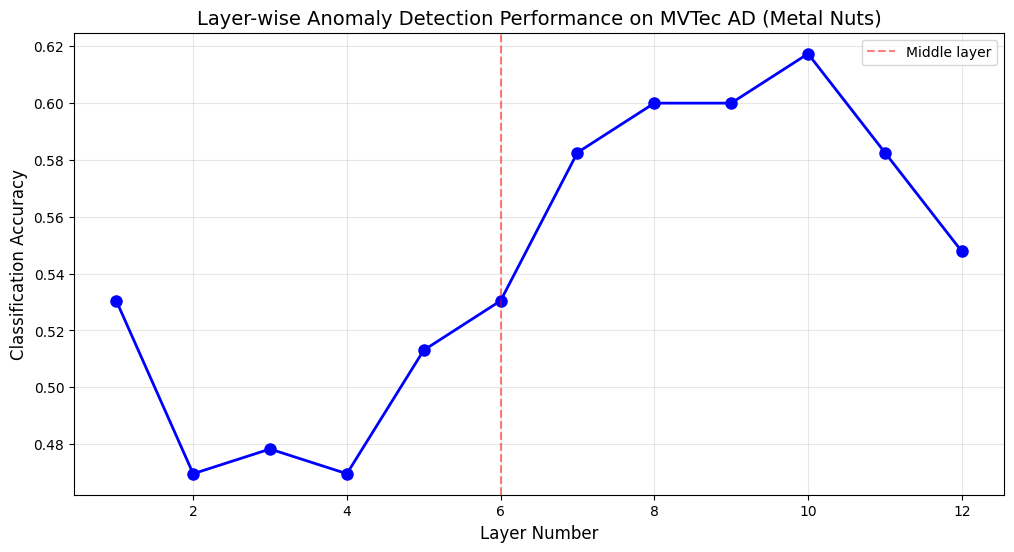

In [ ]:
from sklearn.svm import OneClassSVM
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt

results = {}
n_layers = model.config.num_hidden_layers

for layer in range(1, n_layers + 1):
    print(f"Processing layer {layer}...")
    
    X_train = extract_features(model, processor, train_data['image'], layer)
    y_train = np.zeros(len(X_train))
    
    X_test = extract_features(model, processor, test_data['image'], layer)
    y_test = (np.array(test_data['label']) != 0).astype(int)
    
    ocsvm = OneClassSVM(nu=0.1)
    ocsvm.fit(X_train)  
    
    y_pred = ocsvm.predict(X_test)
    y_pred_binary = (y_pred == -1).astype(int)
    
    acc = accuracy_score(y_true=y_test, y_pred=y_pred_binary)
    
    results[layer] = acc
    
    print(f"Layer {layer}: Accuracy = {acc:.4f}")
    
layers = sorted(results.keys())
accs = [results[l] for l in layers]

plt.figure(figsize=(12, 6))
plt.plot(layers, accs, 'bo-', linewidth=2, markersize=8)
plt.xlabel('Layer Number', fontsize=12)
plt.ylabel('Classification Accuracy', fontsize=12)
plt.title('Layer-wise Anomaly Detection Performance on MVTec AD (Metal Nuts)', fontsize=14)
plt.grid(True, alpha=0.3)
plt.axvline(x=n_layers//2, color='r', linestyle='--', alpha=0.5, label='Middle layer')
plt.legend()
plt.show()

Resolving data files:   0%|          | 0/209 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/83 [00:00<?, ?it/s]

Processing layer 1...


100%|██████████| 83/83 [00:17<00:00,  4.84it/s]


Layer 1: Accuracy = 0.6747
Processing layer 2...


...

Layer 10: Accuracy = 0.5542
Processing layer 11...


100%|██████████| 83/83 [00:17<00:00,  4.77it/s]


Layer 11: Accuracy = 0.5301
Processing layer 12...


100%|██████████| 83/83 [00:17<00:00,  4.67it/s]

Layer 12: Accuracy = 0.5060


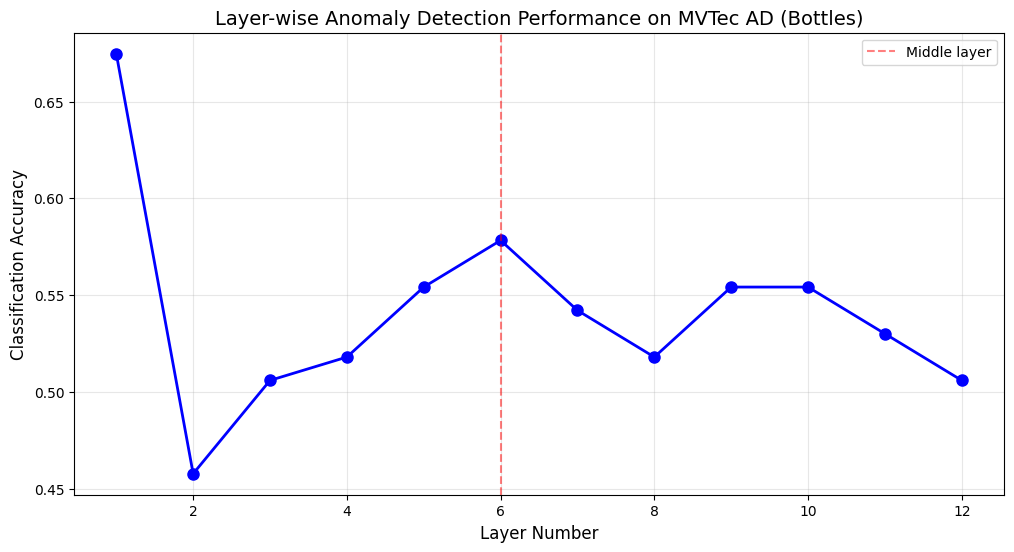

In [8]:
dataset_bottle = load_dataset("bottle")

train_data = dataset_bottle['train']
test_data = dataset_bottle['test']

results = {}
n_layers = model.config.num_hidden_layers

for layer in range(1, n_layers + 1):
    print(f"Processing layer {layer}...")
    
    X_train = extract_features(model, processor, train_data['image'], layer)
    y_train = np.zeros(len(X_train))
    
    X_test = extract_features(model, processor, test_data['image'], layer)
    y_test = (np.array(test_data['label']) != 0).astype(int)
    
    ocsvm = OneClassSVM(nu=0.1)
    ocsvm.fit(X_train)  
    
    y_pred = ocsvm.predict(X_test)
    y_pred_binary = (y_pred == -1).astype(int)
    
    acc = accuracy_score(y_true=y_test, y_pred=y_pred_binary)
    
    results[layer] = acc
    
    print(f"Layer {layer}: Accuracy = {acc:.4f}")
    
layers = sorted(results.keys())
accs = [results[l] for l in layers]

plt.figure(figsize=(12, 6))
plt.plot(layers, accs, 'bo-', linewidth=2, markersize=8)
plt.xlabel('Layer Number', fontsize=12)
plt.ylabel('Classification Accuracy', fontsize=12)
plt.title('Layer-wise Anomaly Detection Performance on MVTec AD (Bottles)', fontsize=14)
plt.grid(True, alpha=0.3)
plt.axvline(x=n_layers//2, color='r', linestyle='--', alpha=0.5, label='Middle layer')
plt.legend()
plt.show()

Результаты у меня разнятся. С одной стороны: на металлической шестерне, дейстивтельно, был наилучшим не самый последний слой, а 10-ый (к концу точность падает). Но на бутылках, казалось бы, неожиданно, лучший результат показывает самый первый слой. Какие у меня идеи?  
На металлических шестернях деффекты не сильно заметные (любой деффект будь то изменение цвета, механическое повреждение и тд, я списывал к аномалии), поэтому, как в статье и было написано, серединные/предпоследние слои более четкие представления получают об изображении. Тогда как для бутылки важны геометрические паттерны (явные сколы, трещины), которые лучше обрабатываются на первых слоях (но что интересно, даже тут средние слои обладают лучшей репрезентативностью, нежели последние)